# Round 2: ML Training with Top 4 Features

Using only: **num_O, TPSA, HBA, HOMO**

Paper reports:
- ROC AUC = 0.87 ± 0.06
- Accuracy = 0.84
(Random Forest, 10-fold StratifiedShuffleSplit)

In [1]:
import sys
sys.path.insert(0, '..')
import pickle
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_dataset
from src.preprocessing import preprocess_data, split_data, standardize, TOP4_FEATURES
from src.models import get_models, train_and_evaluate, cross_validate_model

df = load_dataset()
print(f"Top 4 features: {TOP4_FEATURES}")

X4, y4 = preprocess_data(df, select_features=TOP4_FEATURES)
X4_train, X4_test, y4_train, y4_test = split_data(X4, y4, test_size=0.15)
X4_train_s, X4_test_s, scaler4 = standardize(X4_train, X4_test)

print(f"Train: {X4_train.shape}, Test: {X4_test.shape}")

Top 4 features: ['num_O', 'TPSA', 'HBA', 'HOMO']
Train: (226, 4), Test: (41, 4)


In [2]:
# Train all 5 models
models = get_models()
results_r2 = train_and_evaluate(X4_train_s, X4_test_s, y4_train, y4_test, models)

print("\n" + "=" * 65)
print(f"{'Model':<25} {'AUC':>8} {'Accuracy':>10}")
print("=" * 65)
for name, res in results_r2.items():
    print(f"{name:<25} {res['auc']:>8.4f} {res['accuracy']:>10.4f}")
print("=" * 65)
print(f"\nPaper target (RF): AUC = 0.87 +/- 0.06, Accuracy = 0.84")


Model                          AUC   Accuracy
Random Forest               0.8984     0.9024
Gradient Boosting           0.9161     0.9512
XGBoost                     0.9161     0.9024
Logistic Regression         0.8452     0.8537
SVC                         0.7645     0.8780

Paper target (RF): AUC = 0.87 +/- 0.06, Accuracy = 0.84


In [3]:
# 10-fold CV for Random Forest (paper's evaluation protocol)
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv_r2 = cross_validate_model(X4_train_s, y4_train, rf, n_splits=10)

print(f"Random Forest 10-fold CV (4 features):")
print(f"  AUC:      {cv_r2['auc_mean']:.4f} +/- {cv_r2['auc_std']:.4f}")
print(f"  Accuracy: {cv_r2['acc_mean']:.4f} +/- {cv_r2['acc_std']:.4f}")
print(f"\nPaper reports: AUC = 0.87 +/- 0.06, Accuracy = 0.84")

Random Forest 10-fold CV (4 features):
  AUC:      0.7817 +/- 0.0679
  Accuracy: 0.7971 +/- 0.0533

Paper reports: AUC = 0.87 +/- 0.06, Accuracy = 0.84


Saved: /home/yhm/desktop/code/anion-paper/figures/roc_curves_r2.png


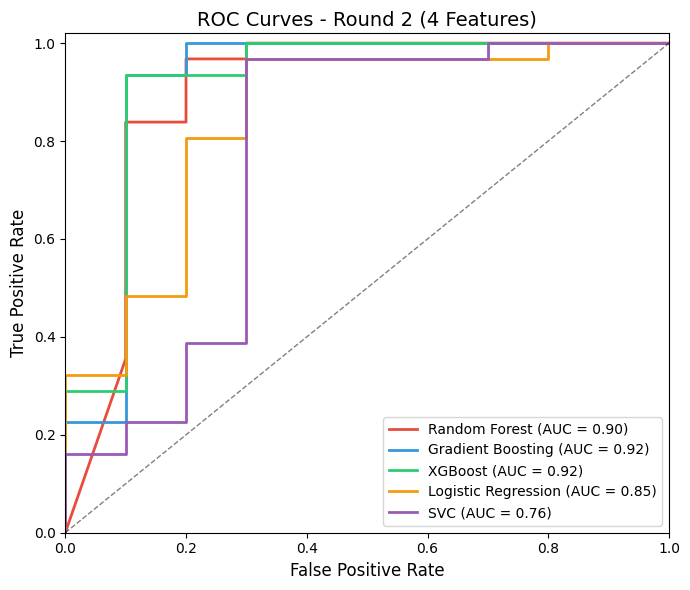

In [4]:
# ROC curves
from src.visualization import plot_roc_curves, save_fig
import matplotlib.pyplot as plt

fig = plot_roc_curves(results_r2, title="ROC Curves - Round 2 (4 Features)")
save_fig(fig, "roc_curves_r2.png")
plt.show()

Saved: /home/yhm/desktop/code/anion-paper/figures/roc_mean_cv_r2.png


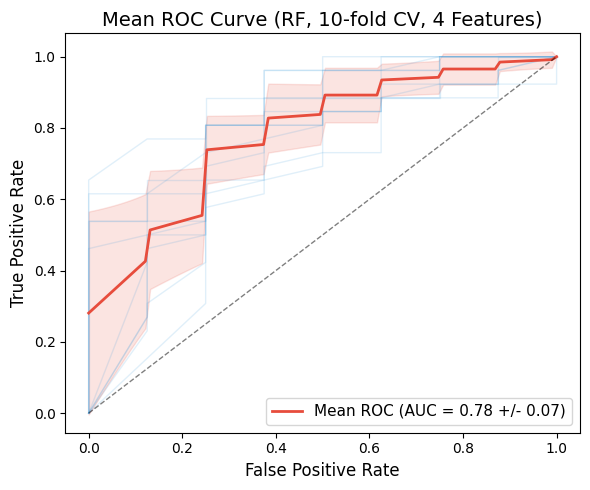

In [5]:
# Mean ROC with CV bands
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from src.visualization import plot_roc_with_cv, save_fig

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.15, random_state=42)
fprs, tprs, aucs = [], [], []

for train_idx, test_idx in splitter.split(X4_train_s, y4_train):
    rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_cv.fit(X4_train_s.iloc[train_idx], y4_train[train_idx])
    y_prob = rf_cv.predict_proba(X4_train_s.iloc[test_idx])[:, 1]
    fpr, tpr, _ = roc_curve(y4_train[test_idx], y_prob)
    fprs.append(fpr)
    tprs.append(tpr)
    aucs.append(roc_auc_score(y4_train[test_idx], y_prob))

fig = plot_roc_with_cv(fprs, tprs, np.mean(aucs), np.std(aucs),
                        title="Mean ROC Curve (RF, 10-fold CV, 4 Features)")
save_fig(fig, "roc_mean_cv_r2.png")
plt.show()

Saved: /home/yhm/desktop/code/anion-paper/figures/lr_coefficients_r2.png


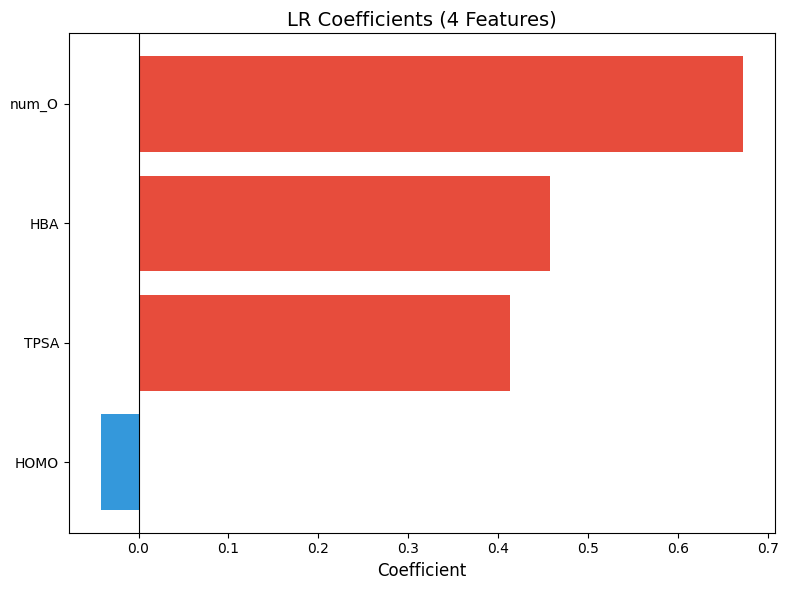

LR Coefficients (sorted):
        HOMO: -0.0421 (negative (lower Eb))
        TPSA: +0.4124 (positive (higher Eb))
         HBA: +0.4578 (positive (higher Eb))
       num_O: +0.6717 (positive (higher Eb))


In [6]:
# Logistic Regression coefficients
from src.models import get_feature_importance
from src.visualization import plot_lr_coefficients, save_fig

lr_model = results_r2['Logistic Regression']['model']
lr_coef = dict(zip(TOP4_FEATURES, lr_model.coef_[0]))
fig = plot_lr_coefficients(lr_coef, title="LR Coefficients (4 Features)")
save_fig(fig, "lr_coefficients_r2.png")
plt.show()

print("LR Coefficients (sorted):")
for feat, coef in sorted(lr_coef.items(), key=lambda x: x[1]):
    direction = "positive (higher Eb)" if coef > 0 else "negative (lower Eb)"
    print(f"  {feat:>10}: {coef:+.4f} ({direction})")

In [7]:
# Save results
with open('../data/results_round2.pkl', 'wb') as f:
    pickle.dump({'results': results_r2, 'feature_names': TOP4_FEATURES, 'cv': cv_r2}, f)

# Also save preprocessed round 2 data
with open('../data/preprocessed_round2.pkl', 'wb') as f:
    pickle.dump({
        'X_train_s': X4_train_s, 'X_test_s': X4_test_s,
        'y_train': y4_train, 'y_test': y4_test,
        'feature_names': TOP4_FEATURES,
    }, f)
print("Round 2 results and data saved.")

Round 2 results and data saved.
